In [ ]:
!uv pip install -q langchain-groq langchain-core pydantic requests \
                pandas scikit-learn matplotlib seaborn tqdm

In [29]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET

from tqdm.notebook import tqdm
from urllib.parse import quote
from typing import Literal

from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)


In [31]:
# ============================================================
# API KEYS (ADD YOUR 4 KEYS)
# ============================================================


API_KEYS = [
    "your_api_key",
    "your_api_key",


]
# MODEL = "llama-3.1-8b-instant"
MODEL = "llama-3.3-70b-versatile"
CHUNK_SIZE = 53

In [32]:
# ============================================================
# PYDANTIC OUTPUT
# ============================================================

class VerificationVerdict(BaseModel):

    verdict: Literal["REAL", "FAKE"] = Field(
        description=(
            "REAL only if the evidence clearly supports the full claim as stated, "
            "including every qualifier such as all, every, only, permanently. "
            "FAKE if the claim is false, contradicted, overstated relative to evidence, "
            "or if no relevant evidence exists."
        )
    )

In [33]:
# ============================================================
# CREATE MODEL FROM KEY
# ============================================================

def create_llm(api_key):

    llm = ChatGroq(
        model=MODEL,
        api_key=api_key,
        temperature=0.0,
        max_tokens=50,
    )

    return llm.with_structured_output(
        VerificationVerdict,
        #method="json_schema"
    )

In [34]:
# ============================================================
# ORIGINAL SYSTEM PROMPT (UNCHANGED)
# ============================================================

SYSTEM_PROMPT = """You are a rigorous fact-checker.
You will be given a CLAIM and EVIDENCE articles headlines from recent news sources.

Your only job is to classify the claim as REAL or FAKE.

Rules:
- REAL: evidence clearly supports the full claim as stated.
  Every qualifier in the claim (all, every, only, permanently, etc.) must be satisfied.
- FAKE: evidence contradicts the claim, no relevant evidence exists,
  or the claim overstates what sources actually say.
- Match the claim's exact wording — do not give benefit of the doubt on scope words."""

In [35]:
# ============================================================
# EVIDENCE FETCHER (UNCHANGED)
# ============================================================

NEWS_ARTICLES_PER_CLAIM = 5

def fetch_evidence(claim_text: str, n: int = NEWS_ARTICLES_PER_CLAIM):

    query   = " ".join(claim_text.split()[:10])
    encoded = quote(query)

    url = f"https://news.google.com/rss/search?q={encoded}&hl=en-US&gl=US&ceid=US:en"

    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status()

        root = ET.fromstring(resp.content)
        channel = root.find("channel")

        if channel is None:
            return []

        articles = []

        for item in list(channel.findall("item"))[:n]:

            src_el = item.find("source")

            articles.append({
                "title": item.findtext("title") or "",
                "description": (item.findtext("description") or "")[:400],
                "source": src_el.text if src_el is not None else "Google News",
                "published_at": item.findtext("pubDate") or "",
            })

        return articles

    except:
        return []

def _build_evidence_text(articles):

    if not articles:
        return "\n(No evidence articles retrieved — treat claim as baseless)\n"

    lines = []

    for i, art in enumerate(articles, 1):
        lines.append(
            f"[{i}] {art['source']} ({art['published_at'][:16]})\n"
            f"Title: {art['title']}\n"
            f"Summary: {art['description']}"
        )

    return "\n".join(lines)

In [36]:
# ============================================================
# PREDICT (UNCHANGED LOGIC)
# ============================================================

def agent2_predict(claim_text, structured_llm, retry=3):

    articles = fetch_evidence(claim_text)
    evidence_text = _build_evidence_text(articles)

    user_msg = (
        f'CLAIM (verify this exact wording including all scope qualifiers):\n'
        f'"{claim_text}"\n\n'
        f'EVIDENCE ARTICLES:\n{evidence_text}'
    )

    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=user_msg)
    ]

    for attempt in range(retry):

        try:
            result = structured_llm.invoke(messages)

            return {
                "verdict": result.verdict,
                "evidence_count": len(articles),
                "error": None
            }

        except Exception as e:

            err = str(e)

            if "429" in err or "rate_limit" in err.lower():
                wait = 60 * (attempt + 1)
                time.sleep(wait)
            else:
                return {
                    "verdict": "FAKE",
                    "evidence_count": len(articles),
                    "error": err
                }

    return {
        "verdict": "FAKE",
        "evidence_count": len(articles),
        "error": "Max retries exceeded"
    }

In [37]:
# ============================================================
# UPLOAD DATASET
# ============================================================

# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("test_dataset.csv")

In [38]:
# ============================================================
# SAME SETTINGS
# ============================================================

CLAIM_COLUMN = "article"
LABEL_COLUMN = "label"
LABEL_MAP = {0: "FAKE", 1: "REAL"}

DELAY_BETWEEN_REQUESTS = 2

df = df[[CLAIM_COLUMN, LABEL_COLUMN]].dropna()
df["ground_truth"] = df[LABEL_COLUMN].map(LABEL_MAP)
df = df.dropna(subset=["ground_truth"]).reset_index(drop=True)

print("Rows:", len(df))

Rows: 60


In [39]:
# df = df.head(5) # uncomment while testing
print(df)

                                              article  label ground_truth
0   BJP won the west bengal assembly election 2026...      1         REAL
1   Apple faces major antitrust heat in India as c...      1         REAL
2   The US Department of Justice has permanently d...      1         REAL
3   Ahead of Eid-ul-Adha, Adityanath warns Muslims...      1         REAL
4   Do not perform cow sacrifices; never consume b...      1         REAL
5    Madras High Court stays Tamil Nadu Police ord...      1         REAL
6   The consecration ceremony (Pran Pratishtha) of...      1         REAL
7   The Supreme Court of India unanimously upheld ...      1         REAL
8   India successfully hosted the G20 Summit in Ne...      1         REAL
9   ISRO successfully launched the Aditya-L1 missi...      1         REAL
10  The Bharatiya Nyaya Sanhita (BNS) officially r...      1         REAL
11  India inaugurated its newly constructed Parlia...      1         REAL
12  The consecration ceremony (Pran Pr

In [40]:
df['label'].value_counts()

,count
label,
1,30
0,30


In [41]:
len(df)

60

In [ ]:
claim_text = input("Enter News/Claim: ")

# Use any API key
api_key = API_KEYS[0]

structured_llm = create_llm(api_key)

start = time.time()

out = agent2_predict(claim_text, structured_llm)

elapsed = round(time.time() - start, 2)

print("\n" + "=" * 60)

if out["error"] is None:
    print("PREDICTION SUCCESS")
    print(f"Claim     : {claim_text}")
    print(f"Verdict   : {out['verdict']}")
    print(f"Time Taken: {elapsed}s")

else:
    print("ERROR")
    print(f"Claim   : {claim_text}")
    print(f"Message : {out['error']}")

print("=" * 60)

Enter News/Claim: ISRO was recruiting astronauts through WhatsApp applications.

PREDICTION SUCCESS
Claim     : ISRO was recruiting astronauts through WhatsApp applications.
Verdict   : FAKE
Time Taken: 0.42s


In [42]:
print(len(df))

60


In [44]:
from tqdm import tqdm
import time

# Optional but recommended
df = df.reset_index(drop=True)

results = []

# One progress bar for the full dataset
pbar = tqdm(total=len(df), desc="Processing rows", unit="row")

for start_idx in range(0, len(df), CHUNK_SIZE):

    end_idx = min(start_idx + CHUNK_SIZE, len(df))

    key_no = (start_idx // CHUNK_SIZE) % len(API_KEYS)
    api_key = API_KEYS[key_no]

    print("=" * 60)
    print(f"Rows {start_idx} to {end_idx - 1}")
    print(f"Using API KEY {key_no + 1}")
    print("=" * 60)

    structured_llm = create_llm(api_key)
    chunk_df = df.iloc[start_idx:end_idx]

    for offset, (_, row) in enumerate(chunk_df.iterrows(), start=0):

        claim_text = str(row[CLAIM_COLUMN])

        start = time.time()
        out = agent2_predict(claim_text, structured_llm)
        elapsed = round(time.time() - start, 2)

        # Actual row number in the full dataframe
        row_no = start_idx + offset + 1

        if out["error"] is None:
            print(f"Row {row_no}: SUCCESS | Verdict = {out['verdict']} | {elapsed}s")
        else:
            print(f"Row {row_no}: ERROR")
            print(f"Claim: {claim_text[:120]}")
            print(f"Message: {out['error']}")
            print("-" * 60)

        results.append({
            "claim": claim_text,
            "ground_truth": row["ground_truth"],
            "verdict": out["verdict"],
            "latency_seconds": elapsed,
            "error": out["error"]
        })

        pbar.update(1)
        time.sleep(DELAY_BETWEEN_REQUESTS)

pbar.close()


# from tqdm import tqdm
# import time

# # Optional but recommended
# df = df.reset_index(drop=True)

# results = []

# # Use ONLY ONE API KEY
# api_key = API_KEYS[0]

# # Create LLM once
# structured_llm = create_llm(api_key)

# # One progress bar for the full dataset
# pbar = tqdm(total=len(df), desc="Processing rows", unit="row")

# for start_idx in range(0, len(df), CHUNK_SIZE):

#     end_idx = min(start_idx + CHUNK_SIZE, len(df))

#     print("=" * 60)
#     print(f"Rows {start_idx} to {end_idx - 1}")
#     print("Using SINGLE API KEY")
#     print("=" * 60)

#     chunk_df = df.iloc[start_idx:end_idx]

#     for offset, (_, row) in enumerate(chunk_df.iterrows(), start=0):

#         claim_text = str(row[CLAIM_COLUMN])

#         start = time.time()
#         out = agent2_predict(claim_text, structured_llm)
#         elapsed = round(time.time() - start, 2)

#         # Actual row number in the full dataframe
#         row_no = start_idx + offset + 1

#         if out["error"] is None:
#             print(f"Row {row_no}: SUCCESS | Verdict = {out['verdict']} | {elapsed}s")
#         else:
#             print(f"Row {row_no}: ERROR")
#             print(f"Claim: {claim_text[:120]}")
#             print(f"Message: {out['error']}")
#             print("-" * 60)

#         results.append({
#             "claim": claim_text,
#             "ground_truth": row["ground_truth"],
#             "verdict": out["verdict"],
#             "latency_seconds": elapsed,
#             "error": out["error"]
#         })

#         pbar.update(1)
#         time.sleep(DELAY_BETWEEN_REQUESTS)

# pbar.close()


Processing rows:   2%|▏         | 1/60 [00:33<33:11, 33.75s/row]


Rows 0 to 52
Using API KEY 1



Processing rows:   2%|▏         | 1/60 [00:00<00:51,  1.15row/s]

Row 1: SUCCESS | Verdict = REAL | 0.47s



Processing rows:   3%|▎         | 2/60 [00:03<01:58,  2.04s/row]

...


Processing rows:  98%|█████████▊| 59/60 [06:52<00:03,  3.50s/row]

Row 59: SUCCESS | Verdict = FAKE | 0.9s



Processing rows: 100%|██████████| 60/60 [06:54<00:00,  3.24s/row]

Row 60: SUCCESS | Verdict = FAKE | 0.63s


Processing rows: 100%|██████████| 60/60 [06:56<00:00,  6.95s/row]


In [50]:
# ============================================================
# FINAL EVALUATION AFTER FULL DATASET
# ============================================================

results_df = pd.DataFrame(results)
results_df.to_csv("agent2_groq_results.csv", index=False)

y_true = results_df["ground_truth"]
y_pred = results_df["verdict"]

print("="*60)
print("FINAL REPORT")
print("="*60)

print(classification_report(
    y_true, y_pred,
    labels=["REAL","FAKE"],
    zero_division=0
))

acc  = round(accuracy_score(y_true, y_pred),4)
f1   = round(f1_score(y_true, y_pred, average="macro"),4)
prec = round(precision_score(y_true, y_pred, average="macro"),4)
rec  = round(recall_score(y_true, y_pred, average="macro"),4)

print("Accuracy :", acc)
print("Macro F1 :", f1)
print("Precision:", prec)
print("Recall   :", rec)



FINAL REPORT
              precision    recall  f1-score   support

        REAL       0.92      0.77      0.84        30
        FAKE       0.80      0.93      0.86        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

Accuracy : 0.85
Macro F1 : 0.849
Precision: 0.86
Recall   : 0.85


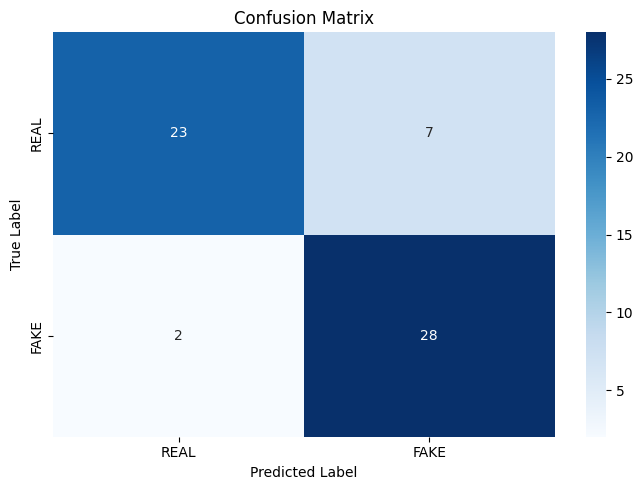

In [47]:
# ----------------------------
# CONFUSION MATRIX PLOT
# ----------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["REAL", "FAKE"]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [51]:
summary = pd.DataFrame([{
    'Method'         : f'SIFACT Agent 2 — Groq ({MODEL}) + Pydantic',
    'Samples'        : len(results_df),
    'Accuracy'       : acc,
    'Macro-F1'       : f1,
    'Precision'      : prec,
    'Recall'         : rec,
    'Avg Latency (s)': round(results_df['latency_seconds'].mean(), 2),
}])

print('=== Final Metrics for Research Paper ===')
print(summary.to_string(index=False))
summary.to_csv('agent2_groq_final_metrics.csv', index=False)
print('\nSaved: agent2_groq_final_metrics.csv')

=== Final Metrics for Research Paper ===
                                                    Method  Samples  Accuracy  Macro-F1  Precision  Recall  Avg Latency (s)
SIFACT Agent 2 — Groq (llama-3.3-70b-versatile) + Pydantic       60      0.85     0.849       0.86    0.85             4.93

Saved: agent2_groq_final_metrics.csv


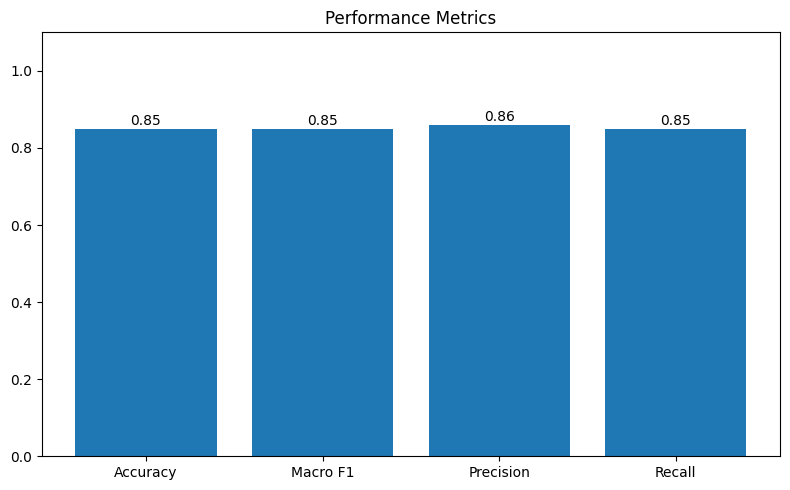

In [46]:
# ----------------------------
# BAR PLOT OF METRICS
# ----------------------------

metric_names = ["Accuracy", "Macro F1", "Precision", "Recall"]
metric_values = [acc, f1, prec, rec]

plt.figure(figsize=(8,5))

bars = plt.bar(metric_names, metric_values)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.2f}",
        ha="center"
    )

plt.ylim(0, 1.1)
plt.title("Performance Metrics")
plt.tight_layout()
plt.savefig("metrics_barplot.png", dpi=300)
plt.show()


In [48]:
import os

# ----------------------------
# SAVE FULL RESULTS
# ----------------------------

results_df.to_excel("agent2_full_results.xlsx", index=False)

# ----------------------------
# DOWNLOAD FILES
# ----------------------------

from google.colab import files

if os.path.exists("agent2_full_results.xlsx"):
    files.download("agent2_full_results.xlsx")
else:
    print("Warning: agent2_full_results.xlsx not found, skipping download.")

if os.path.exists("agent2_groq_final_metrics.csv"):
    files.download("agent2_groq_final_metrics.csv")
else:
    print("Warning: agent2_groq_final_metrics.csv not found, skipping download.")

if os.path.exists("confusion_matrix.png"):
    files.download("confusion_matrix.png")
else:
    print("Warning: confusion_matrix.png not found, skipping download.")

if os.path.exists("metrics_barplot.png"):
    files.download("metrics_barplot.png")
else:
    print("Warning: metrics_barplot.png not found, skipping download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>